<a href="https://colab.research.google.com/github/Randomz4-debug/GoogleCollab-Projects/blob/main/MNISTDATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [64]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

28
28
28
28


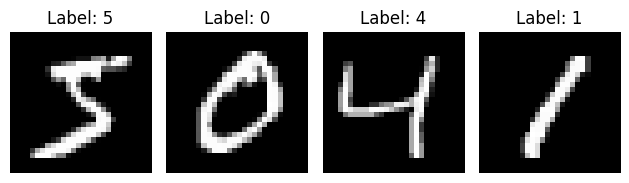

In [65]:
for i in range(4):
  plt.subplot(1, 4, i + 1)
  plt.imshow(X_train[i], cmap="gray")
  plt.title(f"Label: {Y_train[i]}")
  plt.axis("off")

  print(X_train[i].shape[1])

plt.tight_layout()
plt.show()

In [66]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [73]:
class Model(nn.Module):
  def __init__(self, drop_out=0.0):
    super().__init__()

    self.nnLayers = nn.ModuleList()

    self.nnLayers.append(nn.Linear(784, 128))
    self.nnLayers.append(nn.Linear(128, 64))
    self.nnLayers.append(nn.Linear(64, 10))

    self.drop_out = nn.Dropout(drop_out)

  def forward(self, x):
    # Apply each layer with ReLU activation, except the last one
    for i in range(len(self.nnLayers) - 1):
      x = self.nnLayers[i](x)
      x = self.drop_out(x)
      x = F.relu(x)

    # Apply the last layer without ReLU
    x = self.nnLayers[-1](x)

    return x

In [85]:
model = Model()

In [122]:
criterion = nn.CrossEntropyLoss()

optim = torch.optim.Adam(model.parameters(), lr=0.006)

In [119]:
epochs = 500
losses = []

# Prepare X_train_tensor once, outside the epoch loop
# This flattens each 28x28 image to a 784-element vector, resulting in shape (60000, 784)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).view(-1, 784)

for epoch in range(epochs):
  # Now, y_pred for the entire batch
  y_pred = model.forward(X_train_tensor)

  # Use Y_train as a long tensor for CrossEntropyLoss
  loss = criterion(y_pred, torch.tensor(Y_train, dtype=torch.long))
  losses.append(loss.item())

  if epoch % 10 == 0:

    print(f"Epoch: {epoch}")
    print(f"loss: {loss}")

    optim.zero_grad()
    loss.backward()
    optim.step()

Epoch: 0
loss: 0.10766568779945374
Epoch: 10
loss: 0.10681381821632385
Epoch: 20
loss: 0.10619425773620605
Epoch: 30
loss: 0.10564658045768738
Epoch: 40
loss: 0.10503134876489639
Epoch: 50
loss: 0.10426177084445953
Epoch: 60
loss: 0.10333919525146484
Epoch: 70
loss: 0.10233528912067413
Epoch: 80
loss: 0.10135374963283539
Epoch: 90
loss: 0.1004830151796341
Epoch: 100
loss: 0.09973211586475372
Epoch: 110
loss: 0.09905228763818741
Epoch: 120
loss: 0.0983908474445343
Epoch: 130
loss: 0.0977286696434021
Epoch: 140
loss: 0.09706854075193405
Epoch: 150
loss: 0.09640135616064072
Epoch: 160
loss: 0.09572101384401321
Epoch: 170
loss: 0.09503935277462006
Epoch: 180
loss: 0.09436872601509094
Epoch: 190
loss: 0.0937071293592453
Epoch: 200
loss: 0.09304511547088623
Epoch: 210
loss: 0.09239302575588226
Epoch: 220
loss: 0.09177665412425995
Epoch: 230
loss: 0.09120865166187286
Epoch: 240
loss: 0.09067058563232422
Epoch: 250
loss: 0.0901263952255249
Epoch: 260
loss: 0.08954979479312897
Epoch: 270
loss: 

In [120]:
torch.save(model.state_dict(), "model.pt")

In [ ]:
torch.load("model.pt")

In [121]:
correct = 0
total = int(len(X_test)/10)
print(total)

with torch.no_grad():
  for i in range(total):
    y_pred = model.forward(torch.tensor(X_test, dtype=torch.float32).view(-1, 784))

    print(f"{i+1}) Predicted: {torch.argmax(y_pred[i])}, Actual: {Y_test[i]}")

    if torch.argmax(y_pred[i]) == Y_test[i]:
      correct += 1

print(f"Accuracy: {correct / total}")

1000
1) Predicted: 7, Actual: 7
2) Predicted: 2, Actual: 2
3) Predicted: 1, Actual: 1
4) Predicted: 0, Actual: 0
5) Predicted: 4, Actual: 4
6) Predicted: 1, Actual: 1
7) Predicted: 4, Actual: 4
8) Predicted: 9, Actual: 9
9) Predicted: 6, Actual: 5
10) Predicted: 9, Actual: 9
11) Predicted: 0, Actual: 0
12) Predicted: 6, Actual: 6
13) Predicted: 9, Actual: 9
14) Predicted: 0, Actual: 0
15) Predicted: 1, Actual: 1
16) Predicted: 5, Actual: 5
17) Predicted: 9, Actual: 9
18) Predicted: 7, Actual: 7
19) Predicted: 3, Actual: 3
20) Predicted: 4, Actual: 4
21) Predicted: 9, Actual: 9
22) Predicted: 6, Actual: 6
23) Predicted: 6, Actual: 6
24) Predicted: 5, Actual: 5
25) Predicted: 4, Actual: 4
26) Predicted: 0, Actual: 0
27) Predicted: 7, Actual: 7
28) Predicted: 4, Actual: 4
29) Predicted: 0, Actual: 0
30) Predicted: 1, Actual: 1
31) Predicted: 3, Actual: 3
32) Predicted: 1, Actual: 1
33) Predicted: 3, Actual: 3
34) Predicted: 4, Actual: 4
35) Predicted: 7, Actual: 7
36) Predicted: 2, Actual

0